In [121]:
# Import Packages
!python -m pip install seaborn pandas

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [122]:
# Import data
merged_clean = pd.read_csv('.\data_for_pred3.csv')

merged_clean.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\malen\AppData\Local\Temp\ipykernel_36808\113279564.py:2: SyntaxWarning: invalid escape sequence '\d'
  merged_clean = pd.read_csv('.\data_for_pred3.csv')


,user,date,level,workload,high_pressure,social,high_workload,high_social,sleep,good_sleep,...,stressed_now,tired_now,expect_happy,expect_stressed,expect_tired,activity_minutes,day_of_week,is_weekend,month,week
0,u00,2013-03-25,2.000000,0.0,False,3.500000,False,False,8.0,True,...,NaN,NaN,NaN,NaN,NaN,160.991667,0,False,3,13
1,u00,2013-03-26,2.000000,0.0,False,2.333333,False,False,7.5,True,...,NaN,NaN,NaN,NaN,NaN,160.991667,1,False,3,13
2,u00,2013-03-27,1.000000,0.0,False,4.000000,False,True,8.0,True,...,NaN,NaN,NaN,NaN,NaN,218.500000,2,False,3,13
3,u00,2013-03-28,2.666667,0.0,False,3.000000,False,False,6.5,False,...,NaN,NaN,NaN,NaN,NaN,151.783333,3,False,3,13
4,u00,2013-03-29,2.500000,0.0,False,4.000000,False,True,6.0,False,...,NaN,NaN,NaN,NaN,NaN,260.283333,4,False,3,13


## Look at the data

In [123]:
print("Total observations:", len(merged_clean))

Total observations: 1244


In [124]:
print(merged_clean['user'].nunique())

48


In [125]:
participant_counts = (
    merged_clean.groupby('user')
    .size()
)

print(participant_counts.describe())

count    48.000000
mean     25.916667
std      15.152885
min       3.000000
25%      15.500000
50%      25.000000
75%      35.250000
max      70.000000
dtype: float64


In [126]:
merged_clean[
    ['sleep', 'social', 'workload', 'day_of_week', 'baseline_stress', 
                  'mood_valence', 'activity_minutes']
].isna().mean()

sleep               0.000000
social              0.000000
workload            0.000000
day_of_week         0.000000
baseline_stress     0.024116
mood_valence        0.621383
activity_minutes    0.000000
dtype: float64

## Visualize Correlation

<Axes: >

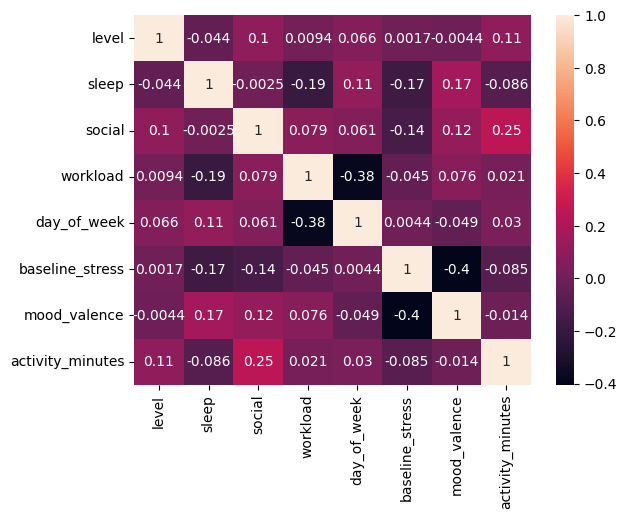

In [127]:
sns.heatmap(
    merged_clean[['level', 'sleep', 'social', 'workload', 'day_of_week', 'baseline_stress', 
                  'mood_valence',  'activity_minutes']].corr(), annot=True)

# Analysis on Behavioral Data

## Random Forest Model

In [128]:
features = ['sleep', 'social', 'workload', 'day_of_week', 'baseline_stress', 'activity_minutes'] #If I use baseline_stress I automatically exclude 3 participants

# Remove missing values
model_data = merged_clean.dropna(subset=features + ['level'])

X = model_data[features]
y = model_data['level']

groups = model_data['user']

In [129]:
#Create test set
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=88
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

print("Train observations:", len(X_train))
print("Test observations:", len(X_test))

Train observations: 972
Test observations: 242


## Validation (K-fold validation)

In [130]:
#K fold cross validation
gkf = GroupKFold(n_splits=5)

mae_scores = []
r2_scores = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(
    gkf.split(X_train, y_train, groups=groups_train)
):
    
    # Split fold
    X_fold_train = X_train.iloc[train_fold_idx]
    X_fold_val = X_train.iloc[val_fold_idx]

    y_fold_train = y_train.iloc[train_fold_idx]
    y_fold_val = y_train.iloc[val_fold_idx]

    # Create model
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=88
    )

    # Train
    model.fit(X_fold_train, y_fold_train)

    # Predict
    preds = model.predict(X_fold_val)

    # Evaluate
    mae = mean_absolute_error(y_fold_val, preds)
    r2 = r2_score(y_fold_val, preds)

    mae_scores.append(mae)
    r2_scores.append(r2)

    print(f"Fold {fold+1}")
    print("MAE:", round(mae, 3))
    print("R²:", round(r2, 3))
    print()

Fold 1
MAE: 1.157
R²: -0.176

Fold 2
MAE: 1.057
R²: -0.334

Fold 3
MAE: 1.217
R²: -0.237

Fold 4
MAE: 0.874
R²: -0.022

Fold 5
MAE: 1.085
R²: -0.123



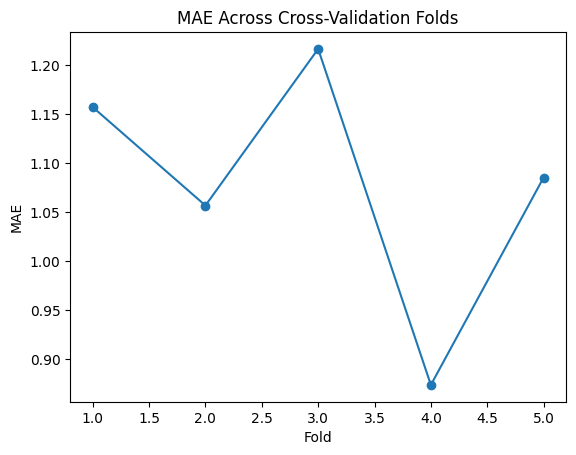

In [131]:
#Visualization of MAE scores in cross validation
plt.plot(
    range(1, len(mae_scores)+1),
    mae_scores,
    marker='o'
)

plt.title("MAE Across Cross-Validation Folds")
plt.xlabel("Fold")
plt.ylabel("MAE")

plt.show()

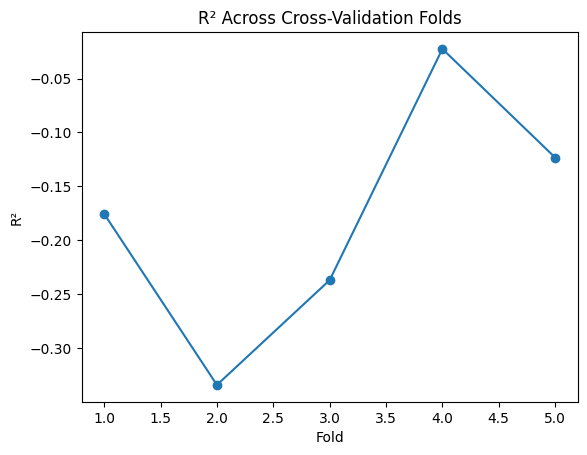

In [132]:
# Visualization of R^2 in cross validation
plt.plot(
    range(1, len(r2_scores)+1),
    r2_scores,
    marker='o'
)

plt.title("R² Across Cross-Validation Folds")
plt.xlabel("Fold")
plt.ylabel("R²")

plt.show()

In [133]:
# Look at average over the validation sets
print("Average MAE:", np.mean(mae_scores))
print("Average R²:", np.mean(r2_scores))

Average MAE: 1.0780365886388512
Average R²: -0.1784718577741345


## Run the Random Forest Model

In [134]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=88
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [135]:
#Evaluate on testset
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

print("Random Forest Test Results (Behavioral dataset)")
print("MAE:", round(rf_mae, 3))
print("R²:", round(rf_r2, 3))
print("RMSE:", round(rf_rmse, 3))

Random Forest Test Results (Behavioral dataset)
MAE: 1.094
R²: -0.038
RMSE: 1.315


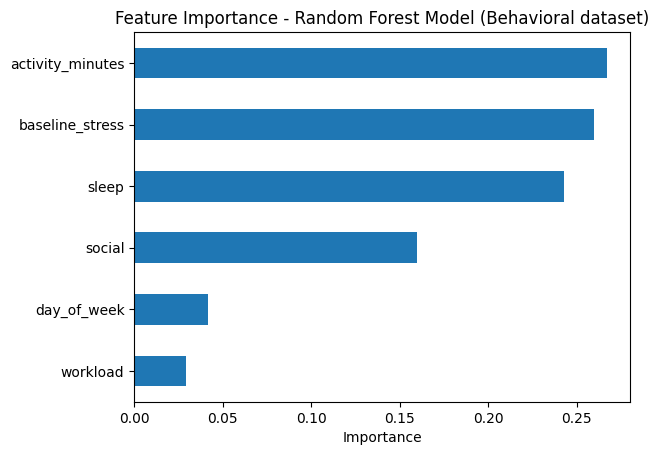

In [136]:
#Feature imprtance

importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values()

importance.plot(kind='barh')

plt.title("Feature Importance - Random Forest Model (Behavioral dataset)")
plt.xlabel("Importance")
plt.show()

In [137]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

            Feature  Importance
5  activity_minutes    0.266857
4   baseline_stress    0.259473
0             sleep    0.242728
1            social    0.159895
3       day_of_week    0.041839
2          workload    0.029208


## Linear Regression

In [138]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)


linear_mae = mean_absolute_error(y_test, linear_preds)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))

linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression Results - Behavioral Dataset")
print("MAE:", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²:", round(linear_r2, 3))

Linear Regression Results - Behavioral Dataset
MAE: 1.095
RMSE: 1.311
R²: -0.031


In [139]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': linear_model.coef_
})

print(coefficients)

            Feature  Coefficient
0             sleep    -0.026902
1            social     0.157611
2          workload     0.029090
3       day_of_week     0.025183
4   baseline_stress     0.003710
5  activity_minutes     0.000879


# Analysis on Behavioral + Mood Valence data 

## Random Forest

In [140]:
features = ['sleep', 'social', 'workload', 'day_of_week', 'baseline_stress', 
                  'mood_valence',  'activity_minutes'] #If I use baseline_stress I automatically exclude 3 participants

# Remove missing values
model_data = merged_clean.dropna(subset=features + ['level'])

X = model_data[features]
y = model_data['level']

groups = model_data['user']

In [141]:
#Create test set
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=88
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

print("Train observations:", len(X_train))
print("Test observations:", len(X_test))


Train observations: 329
Test observations: 142


## Validation (K-fold validation)

In [142]:
#K fold cross validation
gkf = GroupKFold(n_splits=5)

mae_scores = []
r2_scores = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(
    gkf.split(X_train, y_train, groups=groups_train)
):
    
    # Split fold
    X_fold_train = X_train.iloc[train_fold_idx]
    X_fold_val = X_train.iloc[val_fold_idx]

    y_fold_train = y_train.iloc[train_fold_idx]
    y_fold_val = y_train.iloc[val_fold_idx]

    # Create model
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=88
    )

    # Train
    model.fit(X_fold_train, y_fold_train)

    # Predict
    preds = model.predict(X_fold_val)

    # Evaluate
    mae = mean_absolute_error(y_fold_val, preds)
    r2 = r2_score(y_fold_val, preds)

    mae_scores.append(mae)
    r2_scores.append(r2)

    print(f"Fold {fold+1}")
    print("MAE:", round(mae, 3))
    print("R²:", round(r2, 3))
    print()

Fold 1
MAE: 0.908
R²: -0.051

Fold 2
MAE: 0.83
R²: -0.274

Fold 3
MAE: 1.283
R²: -0.254

Fold 4
MAE: 1.102
R²: -0.429

Fold 5
MAE: 1.195
R²: -0.2



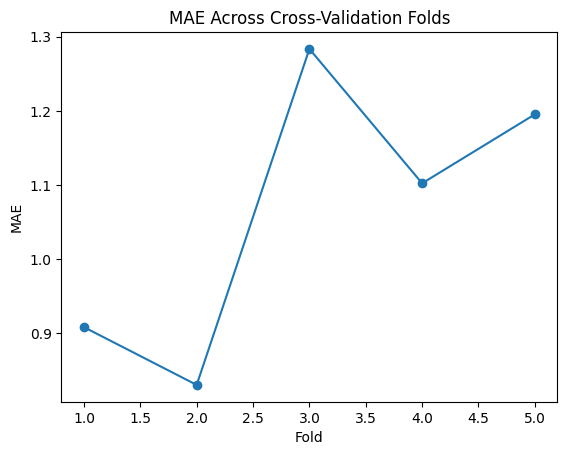

In [143]:
#Visualization of MAE scores in cross validation
plt.plot(
    range(1, len(mae_scores)+1),
    mae_scores,
    marker='o'
)

plt.title("MAE Across Cross-Validation Folds")
plt.xlabel("Fold")
plt.ylabel("MAE")

plt.show()

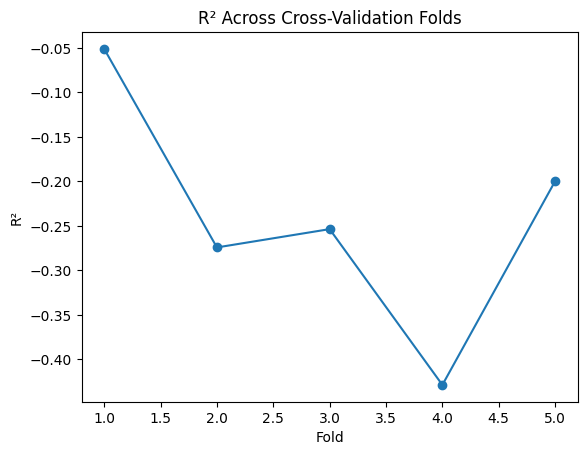

In [144]:
# Visualization of R^2 in cross validation
plt.plot(
    range(1, len(r2_scores)+1),
    r2_scores,
    marker='o'
)

plt.title("R² Across Cross-Validation Folds")
plt.xlabel("Fold")
plt.ylabel("R²")

plt.show()

In [145]:
# Look at average over the validation sets
print("Average MAE:", np.mean(mae_scores))
print("Average R²:", np.mean(r2_scores))

Average MAE: 1.063941350096835
Average R²: -0.24141527395361462


## Run the Random Forest Model

In [146]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=88
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [147]:
#Evaluate on testset
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

print("Random Forest Test Results (Mood dataset)")
print("MAE:", round(rf_mae, 3))
print("R²:", round(rf_r2, 3))
print("RMSE:", round(rf_rmse, 3))

Random Forest Test Results (Mood dataset)
MAE: 0.952
R²: 0.007
RMSE: 1.118


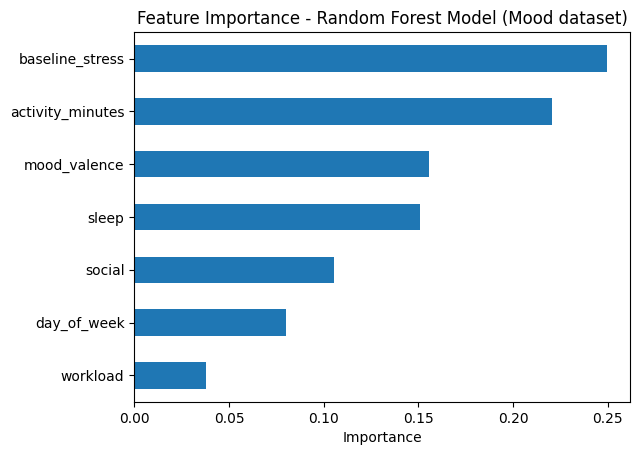

In [148]:
#Feature imprtance

importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values()

importance.plot(kind='barh')

plt.title("Feature Importance - Random Forest Model (Mood dataset)")
plt.xlabel("Importance")
plt.show()

In [149]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

            Feature  Importance
4   baseline_stress    0.249322
6  activity_minutes    0.220461
5      mood_valence    0.155620
0             sleep    0.150714
1            social    0.105705
3       day_of_week    0.080190
2          workload    0.037989


## Linear Regression

In [150]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)


linear_mae = mean_absolute_error(y_test, linear_preds)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))

linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression Results - Mood dataset")
print("MAE:", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²:", round(linear_r2, 3))

Linear Regression Results - Mood dataset
MAE: 0.966
RMSE: 1.147
R²: -0.045


In [151]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': linear_model.coef_
})

print(coefficients)

            Feature  Coefficient
0             sleep    -0.045655
1            social     0.190072
2          workload     0.209482
3       day_of_week     0.080426
4   baseline_stress     0.032946
5      mood_valence     0.071960
6  activity_minutes    -0.000194


# Analysis on Mood Valence dataset but without using mood valence

## Random Forest

In [152]:
# Making reduced dataset
df_full = merged_clean.copy()

df_reduced = df_full.dropna(subset=['mood_valence'])

In [153]:
features = ['sleep', 'social', 'workload', 'day_of_week', 'baseline_stress', 'activity_minutes'] #If I use baseline_stress I automatically exclude 3 participants

# Remove missing values
model_data = df_reduced.dropna(subset=features + ['level'])

X = model_data[features]
y = model_data['level']

groups = model_data['user']

In [154]:
#Create test set
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=88
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

print("Train observations:", len(X_train))
print("Test observations:", len(X_test))

Train observations: 329
Test observations: 142


## Validation (K-fold validation)

In [155]:
#K fold cross validation
gkf = GroupKFold(n_splits=5)

mae_scores = []
r2_scores = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(
    gkf.split(X_train, y_train, groups=groups_train)
):
    
    # Split fold
    X_fold_train = X_train.iloc[train_fold_idx]
    X_fold_val = X_train.iloc[val_fold_idx]

    y_fold_train = y_train.iloc[train_fold_idx]
    y_fold_val = y_train.iloc[val_fold_idx]

    # Create model
    model = RandomForestRegressor(
        n_estimators=100,
        random_state=88
    )

    # Train
    model.fit(X_fold_train, y_fold_train)

    # Predict
    preds = model.predict(X_fold_val)

    # Evaluate
    mae = mean_absolute_error(y_fold_val, preds)
    r2 = r2_score(y_fold_val, preds)

    mae_scores.append(mae)
    r2_scores.append(r2)

    print(f"Fold {fold+1}")
    print("MAE:", round(mae, 3))
    print("R²:", round(r2, 3))
    print()

Fold 1
MAE: 0.923
R²: -0.122

Fold 2
MAE: 0.797
R²: -0.27

Fold 3
MAE: 1.554
R²: -0.959

Fold 4
MAE: 1.092
R²: -0.442

Fold 5
MAE: 1.192
R²: -0.23



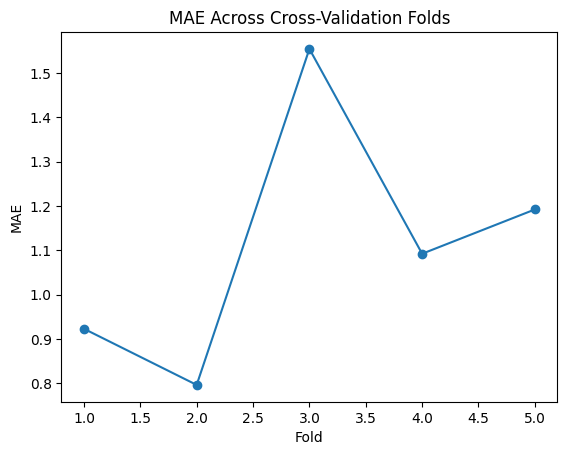

In [156]:
#Visualization of MAE scores in cross validation
plt.plot(
    range(1, len(mae_scores)+1),
    mae_scores,
    marker='o'
)

plt.title("MAE Across Cross-Validation Folds")
plt.xlabel("Fold")
plt.ylabel("MAE")

plt.show()

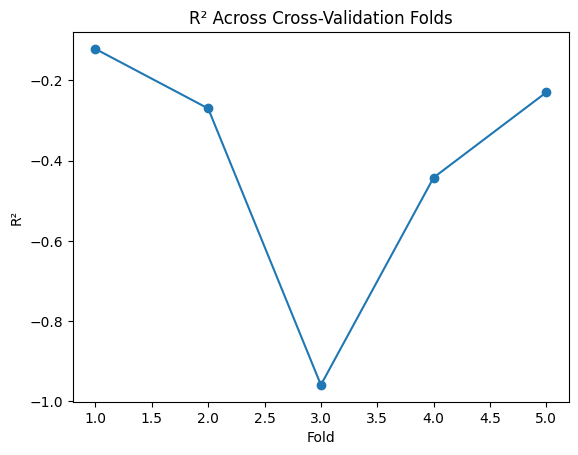

In [157]:
# Visualization of R^2 in cross validation
plt.plot(
    range(1, len(r2_scores)+1),
    r2_scores,
    marker='o'
)

plt.title("R² Across Cross-Validation Folds")
plt.xlabel("Fold")
plt.ylabel("R²")

plt.show()

In [158]:
# Look at average over the validation sets
print("Average MAE:", np.mean(mae_scores))
print("Average R²:", np.mean(r2_scores))

Average MAE: 1.1118569657322364
Average R²: -0.4044116433840725


## Run the Random Forest Model

In [159]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=88
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [160]:
#Evaluate on testset
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Random Forest Test Results - Reduced Dataset")
print("MAE:", round(rf_mae, 3))
print("R²:", round(rf_r2, 3))
print("RMSE:", round(rf_rmse, 3))

Random Forest Test Results - Reduced Dataset
MAE: 0.95
R²: -0.006
RMSE: 1.125


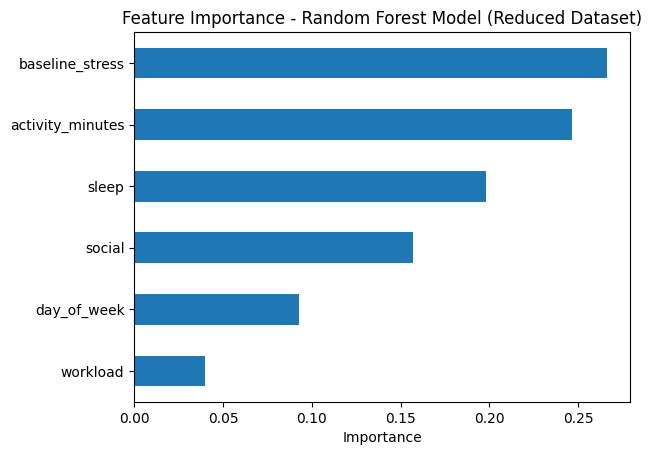

In [161]:
#Feature imprtance

importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values()

importance.plot(kind='barh')

plt.title("Feature Importance - Random Forest Model (Reduced Dataset)")
plt.xlabel("Importance")
plt.show()

In [162]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

            Feature  Importance
4   baseline_stress    0.266002
5  activity_minutes    0.246427
0             sleep    0.198217
1            social    0.156878
3       day_of_week    0.092848
2          workload    0.039629


### Plot stress versus predicted stress

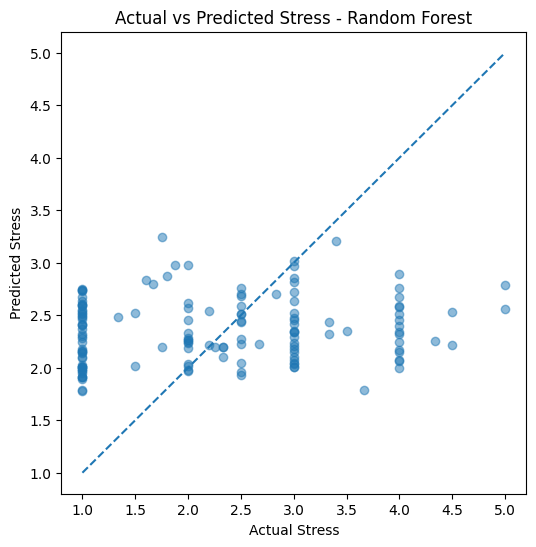

In [163]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    rf_preds,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Stress")
plt.ylabel("Predicted Stress")

plt.title("Actual vs Predicted Stress - Random Forest")

plt.show()

## Linear Regression

In [164]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_preds)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_preds))

linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression Results - Reduced Dataset")
print("MAE:", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²:", round(linear_r2, 3))

Linear Regression Results - Reduced Dataset
MAE: 0.963
RMSE: 1.143
R²: -0.039


In [165]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': linear_model.coef_
})

print(coefficients)

            Feature  Coefficient
0             sleep    -0.042664
1            social     0.188985
2          workload     0.211981
3       day_of_week     0.080522
4   baseline_stress     0.026821
5  activity_minutes    -0.000242


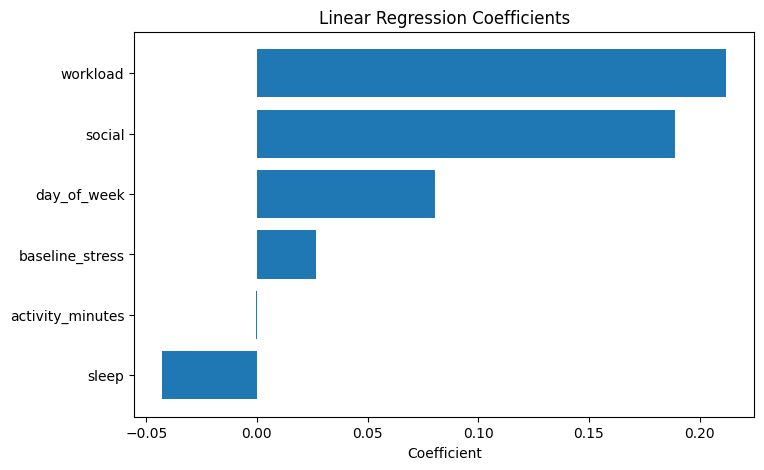

In [166]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': linear_model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient'
)

plt.figure(figsize=(8,5))

plt.barh(
    coefficients['Feature'],
    coefficients['Coefficient']
)

plt.xlabel("Coefficient")
plt.title("Linear Regression Coefficients")

plt.show()

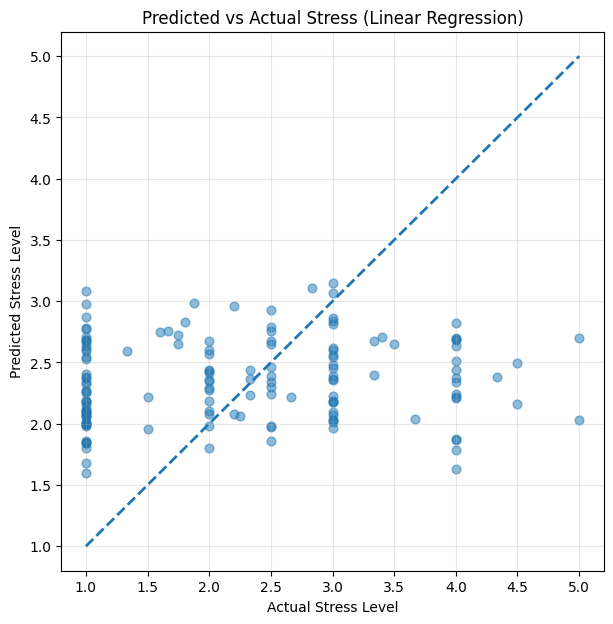

In [170]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    linear_preds,
    alpha=0.5,
    s=40
)

# Perfect prediction line
plt.plot(
    [1, 5],
    [1, 5],
    linestyle='--',
    linewidth=2
)

#plt.xlim(0,5.5)
#plt.ylim(0,5.5)

plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")

plt.title("Predicted vs Actual Stress (Linear Regression)")

plt.grid(alpha=0.3)

plt.show()